Generation of a dark soliton in 1d

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [71]:
L, N = 50.0, 2048
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)
k = 2 * np.pi * fftfreq(N, d=dx)

dt = 0.0001
kappa = 30.0
T_final = 0.843
steps_per_frame = 30
total_frames = int((T_final / dt) / steps_per_frame)
n0 = 1.0
g = 1.0
cs = np.sqrt(g * n0)  
v_obs = 1.5 * cs

# Gaussian potential 
V0 = 12.0      
sigma = 0.7    
x0_start = -L/3

In [72]:
x0_offset = 5.0 

def get_V(t):
    xt1 = -x0_offset + v_obs * t
    xt2 = x0_offset - v_obs * t
    
    v1 = V0 * np.exp(-(x - xt1)**2 / (2 * sigma**2))
    v2 = V0 * np.exp(-(x - xt2)**2 / (2 * sigma**2))
    return v1 + v2

In [73]:
psi = np.full(N, np.sqrt(n0), dtype=np.complex128)

psi_init = psi.copy()

In [74]:
times, densities, energies = [], [], []

def get_stats(p, k_vec, dx_val, kappa):
    dens = np.sum(np.abs(p)**2) * dx_val
    p_hat = fft(p)
    d_psi = ifft(1j * k_vec * p_hat)
    ener = np.sum(0.5 * np.abs(d_psi)**2 + 0.5 * kappa * np.abs(p)**4) * dx_val
    return dens, ener

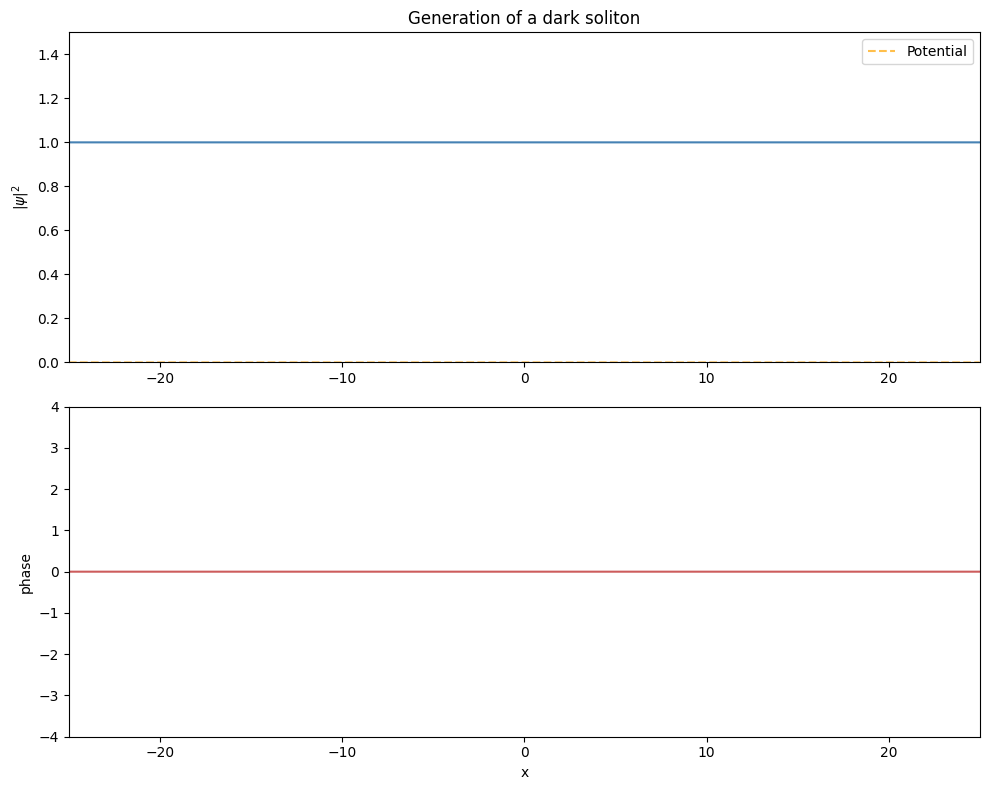

In [75]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
line_dens, = ax1.plot(x, np.abs(psi)**2, color='steelblue')
line_phase, = ax2.plot(x, np.angle(psi), color='indianred')
line_pot, = ax1.plot(x, np.zeros_like(x), color='orange', linestyle='--', alpha=0.7, label='Potential')

ax1.set_ylim(0, 1.5)
ax1.set_xlim(-L/2, L/2)
ax1.set_title("Generation of a dark soliton")
ax1.set_ylabel(fr"$|\psi|^2$")
ax1.legend(loc='upper right')

ax2.set_ylim(-4, 4)
ax2.set_xlim(-L/2, L/2)
ax2.set_ylabel("phase")
ax2.set_xlabel("x")

plt.tight_layout()

In [76]:
aux = 0
def update(frame):
    global psi, aux
    t_frame_start = frame * steps_per_frame * dt
    for s in range(steps_per_frame):
        # TSSP
        t_current = t_frame_start + s * dt
        
        V = get_V(t_current)

        psi *= np.exp(-0.5j * (V+kappa * (np.abs(psi)**2 - 1)) * dt)
        p_hat = fft(psi)
        p_hat *= np.exp(-0.5j * k**2 * dt)
        psi = ifft(p_hat)
        psi *= np.exp(-0.5j * (V+kappa * (np.abs(psi)**2 - 1)) * dt)
    
    aux += 1

    if aux % 10 == 0:
        d, e = get_stats(psi, k, dx, kappa)
        densities.append(d)
        energies.append(e)
        times.append(t_frame_start)

    line_dens.set_ydata(np.abs(psi)**2)
    line_phase.set_ydata(np.angle(psi))

    t_plot = t_frame_start + steps_per_frame * dt
    V_plot = get_V(t_plot)
    line_pot.set_ydata(V_plot / V0)

    ax1.set_title(f"Generation of dark solitons - t = {t_plot:.3f}")

    return line_dens, line_phase

ani = FuncAnimation(fig, update, frames=total_frames, blit=True)
ani.save("dark_solitons_1d_gen/ds1d_gen.html", writer='html')

plt.close()

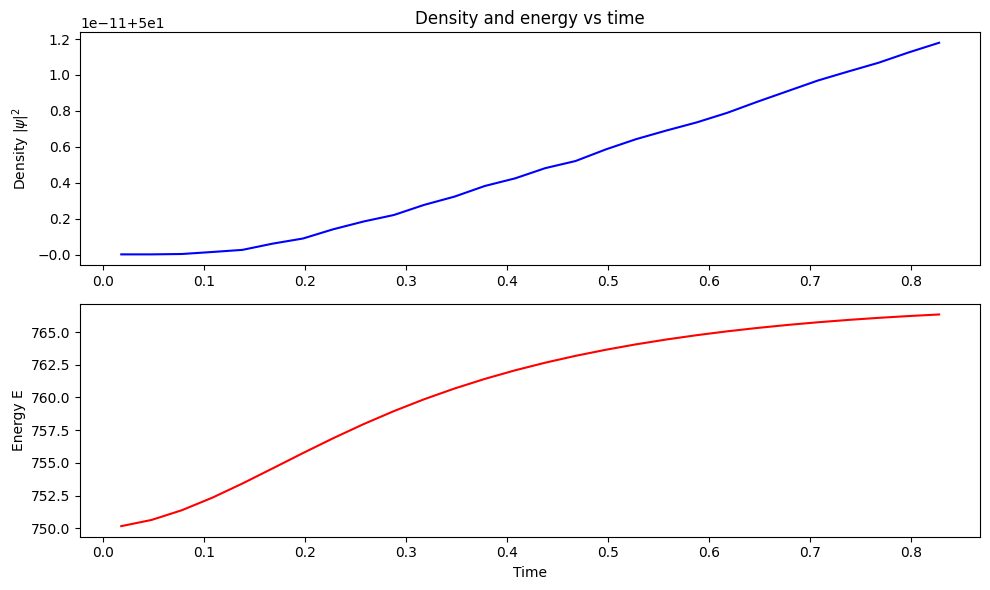

In [77]:
fig_stats, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.set_title("Density and energy vs time")
ax1.plot(times, densities, 'b'); ax1.set_ylabel(r"Density $|\psi|^2$")
ax2.plot(times, energies, 'r'); ax2.set_ylabel("Energy E")
ax2.set_xlabel("Time")
plt.tight_layout()
plt.savefig("dark_solitons_1d_gen/te_ds1d_gen.pdf")
plt.show()